In [1]:
import os
from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langfuse.langchain import CallbackHandler
from langchain_ollama import ChatOllama

load_dotenv()
langfuse_trace = CallbackHandler()


C:\Users\Tho Le\AppData\Local\Temp\ipykernel_7356\1126399824.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
d:\ai_learning\krisknaik\ultimate-rag-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# Old links not work
# urls=[
#     "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
#     "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
#     "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
# ]

urls=[
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphs

In [3]:
doc_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)
doc_splits =text_splitter.split_documents(doc_list)
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=OllamaEmbeddings(
        model="nomic-embed-text"
    ),
)
retriever = vectorstore.as_retriever()

In [4]:
retriever.invoke("what is langgraph")

[Document(id='075909f7-d260-40b5-9c7d-09d45d645a42', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
 Document(id='66fe52f6-3d56-4cde-b6bb-bad05066f170', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'),
 Document(id='7ed4ac1d-0371-494f-990b-9f84ba65a134', metadata={'source': 'https://d

In [5]:
### Retriever To Retriever Tools
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [6]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000209759BE480>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000209759BE5C0>)

### Langchain Blogs- Seperate Vector Store


In [7]:
langchain_urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/rag",
    # "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentJoin our product experts for a "Build More with LangSmith: Summer AMA Series" from July 9-August 12, 2026. RSVP todayDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streami

In [8]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100,
)

doc_splits = text_splitter.split_documents(docs_list)
vectorstorelangchain = FAISS.from_documents(
    documents=doc_splits,
    # embedding=OllamaEmbeddings(model="bge-m3")
    embedding=OllamaEmbeddings(model="nomic-embed-text")
)

retrieverlangchain = vectorstorelangchain.as_retriever()

In [9]:
retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [10]:
tools = [retriever_tool, retriever_tool_langchain]
tools

[StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000209759BE480>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000209759BE5C0>),
 StructuredTool(name='retriever_vector_langchain_blog', description='Search and run information about Langchain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000209759DE980>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000209759DE7A0>)]

### LangGraph Workflow

In [11]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [12]:
from langchain_groq import ChatGroq

# llm_groq = ChatGroq(model="llama-3.1-8b-instant")
# llm_groq.invoke("Hi there!", config={"callbacks": [langfuse_trace]})

In [13]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    
    print("---CALL AGENT---")
    messages = state["messages"]
    # model = ChatGroq(model="llama-3.1-8b-instant")
    # model = ChatGroq(model="llama-3.3-70b-versatile")
    model = ChatOllama(model="gpt-oss", temperature=0)
    llm_bind_tools = model.bind_tools(tools)
    response = llm_bind_tools.invoke(
        messages,
        config={"callbacks": [langfuse_trace]},
    )
    return {"messages": [response]}


In [14]:
from typing import Literal
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field


### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class Grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    # model = ChatGroq(model="llama-3.1-8b-instant")
    # model = ChatGroq(model="llama-3.3-70b-versatile")
    model = ChatOllama(model="gpt-oss", temperature=0)

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(Grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke(
        {"question": question, "context": docs},
        config={"callbacks": [langfuse_trace]}
    )

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """

    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content

    # Prompt - define tay, không cần pull từ LangSmith hub
    prompt = ChatPromptTemplate.from_messages([
        ("human",
         "You are an assistant for question-answering tasks. Use the following pieces "
         "of retrieved context to answer the question. If you don't know the answer, "
         "just say that you don't know. Use three sentences maximum and keep the "
         "answer concise.\n"
         "Question: {question}\nContext: {context}\nAnswer:")
    ])

    # LLM
    # llm = ChatGroq(model="llama-3.3-70b-versatile")
    llm = ChatOllama(model="gpt-oss", temperature=0)

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke(
        {"context": docs, "question": question},
        config={"callbacks": [langfuse_trace]}
    )
    return {"messages": [response]}

In [16]:
from langchain_core.messages import HumanMessage

def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    # model = ChatGroq(model="llama-3.3-70b-versatile")
    model = ChatOllama(model="gpt-oss", temperature=0)
    response = model.invoke(msg, config={"callbacks": [langfuse_trace]})
    return {"messages": [response]}

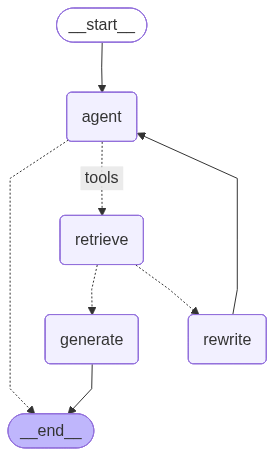

In [17]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool, retriever_tool_langchain])

workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [18]:
graph.invoke({"messages":"What is Langgraph?"}, config={'callbacks': [langfuse_trace]})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='41b8d4cd-a9f4-44fd-a49f-67239144ea1f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2026-07-02T02:56:38.054125685Z', 'done': True, 'done_reason': 'stop', 'total_duration': 183559093637, 'load_duration': 169762791431, 'prompt_eval_count': 178, 'prompt_eval_duration': 4370104000, 'eval_count': 72, 'eval_duration': 9401995000, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--019f20be-f9a9-7d22-9ef0-bcd98b144200-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Langgraph'}, 'id': '1f9b8294-f333-4490-b26d-a2210c815829', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 178, 'output_tokens': 72, 'total_tokens': 250}),
  ToolMessage(content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration

In [19]:
graph.invoke({"messages":"What is Langchain?"}, config={"callbacks": [langfuse_trace]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='a591b473-3560-4579-9ebb-fec8dfe0ddff'),
  AIMessage(content='**LangChain** is an open‑source developer toolkit that makes it easier to build and deploy applications powered by large language models (LLMs). It was created to address the practical challenges of turning a raw LLM into a useful, production‑ready system.\n\n---\n\n### Core ideas\n\n| Concept | What it means in LangChain |\n|---------|---------------------------|\n| **Prompt** | The text you give an LLM. In LangChain prompts are treated as first‑class objects that can be templated, parameterised and reused. |\n| **Chain** | A deterministic sequence of operations (e.g., prompt → LLM call → post‑processing). Chains let you compose simple building blocks into more complex workflows. |\n| **Memory** | State that persists across calls – e.g., conversation history or external knowledge bases. LangChain offers in‑memory, vector‑

In [20]:
graph.invoke({"messages":"What is Machine learning?"}, config={"callbacks": [langfuse_trace]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='f879c365-4628-43fc-baa8-b864fa73d38a'),
  AIMessage(content='**Machine Learning (ML)** is a subfield of artificial intelligence that focuses on building systems capable of automatically improving their performance on a task through experience—without being explicitly programmed for every specific outcome.\n\n### Core Idea\n- **Data‑driven learning:** An ML model learns patterns, relationships, or decision rules from data.\n- **Generalization:** After training, the model should perform well on new, unseen data that comes from the same underlying distribution.\n\n### Key Components\n\n| Component | What it is | Typical Example |\n|-----------|------------|-----------------|\n| **Data** | The raw information used for learning (images, text, sensor readings, etc.). | A dataset of labeled images of cats and dogs. |\n| **Model/Algorithm** | The mathematical structure that maps inpu